In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
from scipy.stats import pointbiserialr

In [108]:
df2 = pd.read_csv('cleaned_joined_data.csv')
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        400000 non-null  int64  
 1   event_id          400000 non-null  int64  
 2   ad_id             400000 non-null  int64  
 3   user_id           400000 non-null  str    
 4   timestamp         400000 non-null  str    
 5   day_of_week       400000 non-null  str    
 6   time_of_day       400000 non-null  str    
 7   event_type        400000 non-null  str    
 8   ad_id:1           400000 non-null  int64  
 9   campaign_id       400000 non-null  int64  
 10  ad_platform       400000 non-null  str    
 11  ad_type           400000 non-null  str    
 12  target_gender     400000 non-null  str    
 13  target_age_group  400000 non-null  str    
 14  target_interests  400000 non-null  str    
 15  campaign_id:1     400000 non-null  int64  
 16  name              400000 non-nu

**Convert Dates' Datatype**

In [109]:
cols = ['start_date','end_date','timestamp']
df2[cols] = df2[cols].apply(pd.to_datetime)
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Unnamed: 0        400000 non-null  int64         
 1   event_id          400000 non-null  int64         
 2   ad_id             400000 non-null  int64         
 3   user_id           400000 non-null  str           
 4   timestamp         400000 non-null  datetime64[us]
 5   day_of_week       400000 non-null  str           
 6   time_of_day       400000 non-null  str           
 7   event_type        400000 non-null  str           
 8   ad_id:1           400000 non-null  int64         
 9   campaign_id       400000 non-null  int64         
 10  ad_platform       400000 non-null  str           
 11  ad_type           400000 non-null  str           
 12  target_gender     400000 non-null  str           
 13  target_age_group  400000 non-null  str           
 14  target_interest

**Advertisment User Events' Type Breakdown**

In [4]:
# Total Advertising records: 400,000

counts = df2['event_type'].value_counts()
proportions = df2['event_type'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'event_type': counts.index,
    'count': counts.values,
    'proportion_%': proportions.values.round(2)
})
summary

,event_type,count,proportion_%
0,impression,339812,84.95
1,click,40079,10.02
2,like,12013,3.00
3,comment,4108,1.03
4,purchase,2031,0.51
5,share,1957,0.49


**Distribution of Ad Impressions across Campaigns**

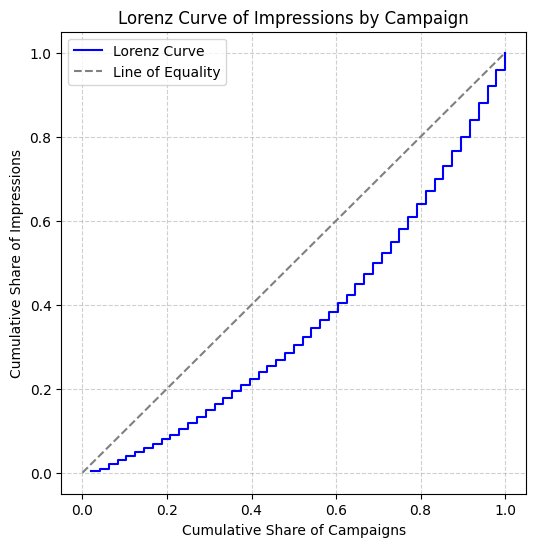

In [110]:
# Step 1: Count impressions per campaign
impressions_per_campaign = df2[df2["event_type"]=="impression"].groupby("campaign_id")["event_type"].count()

# Step 2: Sort values
values = np.sort(impressions_per_campaign.values)
n = len(values)

# Step 3: Calculate cumulative share of campaigns and impressions
cum_campaigns = np.arange(1, n+1) / n
cum_impressions = np.cumsum(values) / values.sum()

# Step 4: Plot Lorenz curve
plt.figure(figsize=(6,6))
plt.plot(cum_campaigns, cum_impressions, drawstyle="steps-post", label="Lorenz Curve", color="blue")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Line of Equality")
plt.title("Lorenz Curve of Impressions by Campaign")
plt.xlabel("Cumulative Share of Campaigns")
plt.ylabel("Cumulative Share of Impressions")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**Insights**
1) The total ad impressions are generated and concentrated among a smaller size of advertisements
2) It is efficient if the intention is to generate most sales from a few dominant ads
3) It is not efficient if the intention is to evenly spread the sales from wide variety of ads

**Creating 1 Target Variable: Purchase & 3 Metrics: Conversion Rate (CR), Cost of Acquisition (CPA), Click Through Rate (CTR) columns**

1) Click-Through Rate (CTR) is an Ad Engagement metric, indicate user interest level
2) CPA and CR are Ad Efficiency metrics

In [111]:
# Calculate no. of events per ad_id
counts = df2.groupby("ad_id")["event_type"].value_counts().unstack(fill_value=0)

# Calculate weighted CTR & CR columns
counts['w_ctr'] = round((counts["click"] / counts["impression"]) * 100,2)
counts['w_cr'] = round((counts["purchase"] / counts["click"]) * 100,2)

# Count purchases per ad_id
purchases_ad = df2[df2["event_type"]=="purchase"].groupby("ad_id").size().rename('purchases')

# Calculate Total Ad Budget per Campaign
campaign_budget = df2.groupby("campaign_id")["total_budget"].first()

# Count number of ads per campaign
ads_campaign = df2.groupby("campaign_id")["ad_id"].nunique()

# Equal Allocation of Budget per ad = total campaign budget/number of ads per campaign
equal_budget = round(campaign_budget / ads_campaign ,2)

# Map back to each ad_id
df2["eq_budget"] = df2["campaign_id"].map(equal_budget)

# Calculate CPA per ad_id = allocated budget / purchases_ad
actual_cpa = round((df2.groupby('ad_id')['eq_budget'].mean() / purchases_ad).rename('w_cpa'),2)

# Create Target Variable column
df2['purchase'] = (df2['event_type']=='purchase').astype(int)   

# Merge 3 metric columns back to original df2
df3 = df2.merge(counts[["w_ctr","w_cr"]], on="ad_id")
df3 = df3.merge(actual_cpa.rename("w_cpa"), on="ad_id")
df3.head()

,Unnamed: 0,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,ad_id:1,campaign_id,...,user_age,age_group,country,location,interests,eq_budget,purchase,w_ctr,w_cr,w_cpa
0,0,1,197,2359b,2025-07-26 00:19:56,saturday,night,like,197,9,...,24,18-24,united states,west shawna,"gaming, food",6682.34,0,12.71,6.05,514.03
1,1,2,51,f9c67,2025-06-15 08:28:07,sunday,morning,share,51,26,...,30,25-34,united states,meyersland,"photography, finance",14846.29,0,10.76,7.45,1060.45
2,2,3,46,5b868,2025-06-27 00:40:02,friday,night,impression,46,10,...,20,18-24,united states,barrerahaven,"fashion, sports, travel",4917.32,0,10.49,7.95,351.24
3,3,4,166,3d440,2025-06-05 19:20:45,thursday,evening,impression,166,14,...,18,18-24,united states,lake angelaland,"food, art",19924.97,0,11.83,3.54,2846.42
4,4,5,52,68f1a,2025-07-22 08:30:29,tuesday,morning,impression,52,2,...,58,55-65,united kingdom,robinsonberg,"finance, lifestyle",26447.47,0,11.49,4.06,3305.93


In [112]:
df3.to_csv('cleaneddata_metrics.csv')

**Spliting User's Interests in separate columns, changing its data type from object to str**

In [6]:
df_interests = df3.assign(interests=df3['interests'].str.split(',')) \
            .explode("interests")       

# Clean white spaces
df_interests['interests'] = df_interests['interests'].str.split()
df4 = df_interests
df4['interests'] = df4['interests'].str[0]    # Extracting 1st item in list 
df4['interests'] = df4['interests'].astype(str)   # Change datatype
df4.head()

,Unnamed: 0,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,ad_id:1,campaign_id,...,user_age,age_group,country,location,interests,eq_budget,purchase,w_ctr,w_cr,w_cpa
0,0,1,197,2359b,2025-07-26 00:19:56,saturday,night,like,197,9,...,24,18-24,united states,west shawna,gaming,6682.34,0,12.71,6.05,514.03
0,0,1,197,2359b,2025-07-26 00:19:56,saturday,night,like,197,9,...,24,18-24,united states,west shawna,food,6682.34,0,12.71,6.05,514.03
1,1,2,51,f9c67,2025-06-15 08:28:07,sunday,morning,share,51,26,...,30,25-34,united states,meyersland,photography,14846.29,0,10.76,7.45,1060.45
1,1,2,51,f9c67,2025-06-15 08:28:07,sunday,morning,share,51,26,...,30,25-34,united states,meyersland,finance,14846.29,0,10.76,7.45,1060.45
2,2,3,46,5b868,2025-06-27 00:40:02,friday,night,impression,46,10,...,20,18-24,united states,barrerahaven,fashion,4917.32,0,10.49,7.95,351.24


**Comparing Target_Age_Group and Age_Group Mismatch % & Calculate Mismatch Metrics**

In [7]:
# Add match/mismatch flag
df3['match'] = df3['target_age_group'] == df3['age_group']

# Step 2: Count events by match flag
event_counts = (
    df3.groupby(['match', 'event_type'])
       .size()
       .unstack(fill_value=0)   # pivot event types into columns
       .reset_index()
)

# Step 3: Calculate CTR and CR
event_counts['CTR'] = round(event_counts['click'] / event_counts['impression'] * 100,2)
event_counts['CR'] = round(event_counts['purchase'] / event_counts['click'] * 100,2)

print(event_counts)

event_type  match  click  comment  impression  like  purchase  share    CTR  \
0           False  31292     3211      265380  9351      1566   1521  11.79   
1            True   8787      897       74432  2662       465    436  11.81   

event_type    CR  
0           5.00  
1           5.29  


In [8]:
# Count total rows
total = len(df3)

# Count mismatches
mismatches = (df3['match'] == False).sum()

# Calculate mismatch percentage
target_group_mismatch = round(mismatches / total * 100,)
print(f" The mismatch proportion of target age group and the actual age group users is {target_group_mismatch}%")

 The mismatch proportion of target age group and the actual age group users is 78%


**Findings**
1) The target age group vs actual user age group mismatch proportion is very high at 78%, means a large part of the ad impressions are delivered outside the target age group users.
2) However, the CTR and conversion rates of both groups are near each other, with the conversion efficiency slight higher for match target age group audience.
3) This might means any ad strategy relating to age group segmenting might not be effective

**Relationship between CPA & Ad Budget**

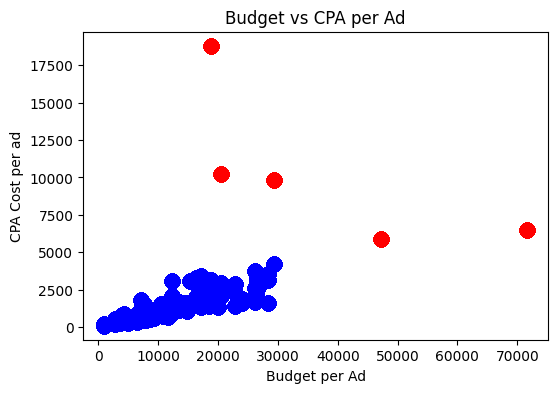

In [84]:
# Detect outliers using Z-score
y = df3['w_cpa']
z_scores = (y-np.mean(y)) / np.std(y)
outliers = np.abs(z_scores) > 2   

plt.figure(figsize=(6,4))

# Majority points in blue
plt.scatter(df3['eq_budget'][~outliers], df3['w_cpa'][~outliers], s=100, c='blue') 
# Outliers points in red
plt.scatter(df3['eq_budget'][outliers], df3['w_cpa'][outliers], s=100, c='red') 

plt.title('Budget vs CPA per Ad')
plt.ylabel('CPA Cost per ad')
plt.xlabel('Budget per Ad')
plt.show()

**Insights (CPA & Ad Budget)**
1) Majority of the CPA cost per ad were concentrated and gradually increases from 0 to $5K as the budget increaased from 0 to $30k, except for a few outliers.
2) This means the CPA cost will increase as ad was being scaled up  instead of remaining constant.

**Relationship between Impressions & Conversion Rate (CR)**

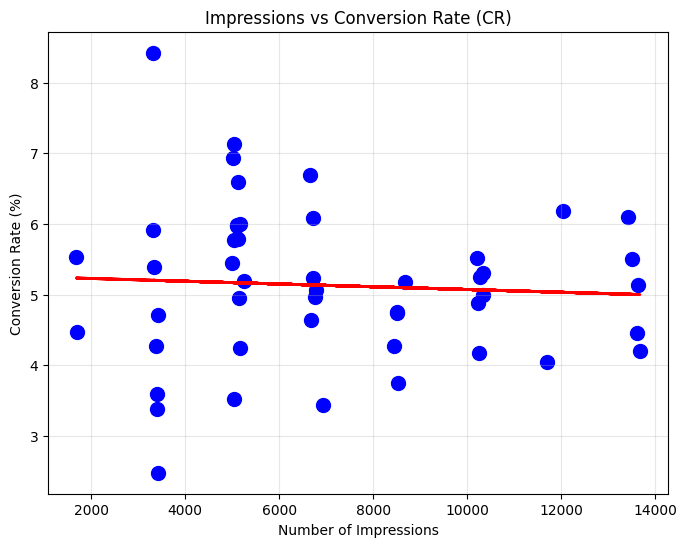

In [77]:
# Group impressions per campaign
impressions = df3[df3["event_type"]=="impression"].groupby("campaign_id").size()

# Group Conversion Rate by campaign (already exists, so just take mean or unique)
cr_values = df3.groupby("campaign_id")["w_cr"].mean()

# Combine both columns into one DataFrame
agg = pd.DataFrame({"impressions": impressions, "CR": cr_values})

# Plot Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(agg["impressions"], agg["CR"],
            color="blue", marker="o", s=100)

# Plot Regression Line
m, b = np.polyfit(agg["impressions"], agg["CR"], 1)
plt.plot(agg["impressions"], m*agg["impressions"] + b, color="red", linewidth=2, label="Trendline")

plt.title("Impressions vs Conversion Rate (CR)")
plt.xlabel("Number of Impressions")
plt.ylabel("Conversion Rate (%)")
plt.grid(alpha=0.3)
plt.show()

**Insights**
1) There is no clear linear relationship between impressions and conversion rate (CR)
2) Majority of the conversion rates concentrated between 3-6% and are stable in this range, even at large impressions
3) Not useful to scale up ads since no increase in conversion rate at large number of impressions
4) Further analysis (see below) are required for more useful insights

**3 Metrics (CPA, CTR, CR) Bin Types (High, Medium or Low) & Value Range**

In [11]:
# CPA Bins
df3['cpa_type'], cpa_bins = pd.qcut(df3['w_cpa'], q=3, labels=['low','medium','high'], retbins=True) 

# CTR Bins
df3['ctr_type'], ctr_bins = pd.qcut(df3['w_ctr'], q=3, labels=['low','medium','high'], retbins=True) 

# CR Bins
df3['cr_type'], cr_bins = pd.qcut(df3['w_cr'], q=3, labels=['low','medium','high'], retbins=True)

# Build Summary Table
summary = pd.DataFrame({
    'CPA': ['Low','Medium','High'],
    'CPA range': [(cpa_bins[i], cpa_bins[i+1]) for i in range(len(cpa_bins)-1)],
    'CTR': ['low','medium','high'],
    'CTR range': [(ctr_bins[i], ctr_bins[i+1]) for i in range(len(ctr_bins)-1)],
    'CR': ['low','medium','high'],
    'CR range': [(cr_bins[i], cr_bins[i+1]) for i in range(len(cr_bins)-1)]
})
summary

,CPA,CPA range,CTR,CTR range,CR,CR range
0,Low,"(82.48, 692.1)",low,"(9.55, 11.44)",low,"(0.5, 4.26)"
1,Medium,"(692.1, 1387.53)",medium,"(11.44, 12.14)",medium,"(4.26, 5.83)"
2,High,"(1387.53, 18804.75)",high,"(12.14, 14.52)",high,"(5.83, 9.89)"


**Relationship between Interests & Conversion Rate (CR), CTR & CPA**

In [12]:
# Calculate mean CR, CTR & CPA
agg_df4 = df4.groupby('interests').agg({'w_cr':'mean','w_cpa':'mean','w_ctr':'mean'}).reset_index()

# Classify CPA, CTR & CR into 3 bins
agg_df4['CPA_type'], cpa_bins = pd.qcut(agg_df4['w_cpa'], q=3, labels = ['Low','Medium','High'], retbins=True)    
agg_df4['CR_type'], cr_bins = pd.qcut(agg_df4['w_cr'], q=3, labels = ['Low','Medium','High'], retbins=True)
agg_df4['CTR_type'], cpa_bins = pd.qcut(agg_df4['w_ctr'], q=3, labels = ['Low','Medium','High'], retbins=True)  

result = agg_df4[['interests','CTR_type', 'CPA_type','CR_type']]
result

,interests,CTR_type,CPA_type,CR_type
0,art,High,Low,Low
1,fashion,Low,Medium,Low
2,finance,Low,High,High
3,fitness,High,Low,High
4,food,Medium,Low,High
5,gaming,Medium,Low,High
6,health,High,High,Medium
7,lifestyle,Low,Medium,Medium
8,news,Low,Medium,Medium
9,photography,Medium,High,Low


**Insights (Interests)**
1) Fitness, food have medium to high user interests, cheap (low cpa) & high purchase (high CR)
2) Art has high interest and cheap but medium purchase, good to build brand awareness
3) Depending on which industry the business is in, can target ad accordingly

**Relationship between Ad_Types & Conversion Rate (CR), CTR & CPA**

In [13]:
# Calculate mean CR, CTR & CPA
agg_df3 = df3.groupby('ad_type').agg({'w_cr':'mean','w_cpa':'mean','w_ctr':'mean'}).reset_index()

# Classify CPA & CR into 3 bins
agg_df3['CPA_type'], cpa_bins = pd.qcut(agg_df3['w_cpa'], q=3, labels = ['Low','Medium','High'], retbins=True)    
agg_df3['CR_type'], cr_bins = pd.qcut(agg_df3['w_cr'], q=3, labels = ['Low','Medium','High'], retbins=True)
agg_df3['CTR_type'], cpa_bins = pd.qcut(agg_df3['w_ctr'], q=3, labels = ['Low','Medium','High'], retbins=True)  

result = agg_df3[['ad_type','CTR_type', 'CPA_type','CR_type']]
result

,ad_type,CTR_type,CPA_type,CR_type
0,carousel,Low,Low,Medium
1,image,Medium,High,Low
2,stories,Low,Medium,High
3,video,High,Low,Low


**Insights (Ad Type)** 
1) Stories: Can lower cpa cost (medium) since it has high conversion rate if want to increase usage of this ad type
2) Image: Should halt this ad type due to high cpa cost and low conversion rate
3) Carousel: Can increase conversion rate (medium) of this ad type 

**Relationship between Age Group & Ad Interest (CTR), Conversion Rates, Cost Per Acquisition (CPA)**

In [15]:
# Calculate mean CR, CTR & CPA
agg_df3 = df3.groupby('age_group').agg({'w_cr':'mean','w_cpa':'mean', 'w_ctr':'mean'}).reset_index()

# Classify CPA & CR into 3 bins
agg_df3['CPA_type'], cpa_bins = pd.qcut(agg_df3['w_cpa'], q=3, labels = ['Low','Medium','High'], retbins=True)    
agg_df3['CR_type'], cr_bins = pd.qcut(agg_df3['w_cr'], q=3, labels = ['Low','Medium','High'], retbins=True)
agg_df3['CTR_type'], cpa_bins = pd.qcut(agg_df3['w_ctr'], q=3, labels = ['Low','Medium','High'], retbins=True)

result = agg_df3[['age_group','CTR_type', 'CPA_type','CR_type']]
result

,age_group,CTR_type,CPA_type,CR_type
0,16-17,Low,Low,Low
1,18-24,Medium,Low,High
2,25-34,Low,Medium,Medium
3,35-44,Medium,Medium,Medium
4,45-54,High,High,High
5,55-65,High,High,Low


**Insights (Age Group)**
1) 18-24 age group is most cost efficient (high CR & low CPA cost). Can increase ad exposure for this group
2) 55-65 age group: Halt this group as it is high cost and low CR
3) 45-54 age group got high CR & CTR, but need to reduce cpa cost if want to target this group

**Relationship between Country & Ad Conversion Rate, CTR & CPA**

In [16]:
# Calculate mean CR, CTR & CPA
agg_df3 = df3.groupby('country').agg({'w_cr':'mean','w_cpa':'mean', 'w_ctr':'mean'}).reset_index()

# Classify CPA & CR into 3 bins
agg_df3['CPA_type'], cpa_bins = pd.qcut(agg_df3['w_cpa'], q=3, labels = ['Low','Medium','High'], retbins=True)    
agg_df3['CR_type'], cr_bins = pd.qcut(agg_df3['w_cr'], q=3, labels = ['Low','Medium','High'], retbins=True)
agg_df3['CTR_type'], cpa_bins = pd.qcut(agg_df3['w_ctr'], q=3, labels = ['Low','Medium','High'], retbins=True)

result = agg_df3[['country','CTR_type', 'CPA_type','CR_type']]
result

,country,CTR_type,CPA_type,CR_type
0,australia,Medium,High,Low
1,brazil,Low,High,Low
2,canada,High,Low,Low
3,france,Low,Medium,High
4,germany,High,Low,Medium
5,india,Low,Low,High
6,japan,Medium,High,High
7,mexico,High,Low,Medium
8,united kingdom,Low,Medium,Low
9,united states,Medium,Medium,Medium


**Insights (Country)**
1) Should target online users from Germany, India & Mexico as they are cheapest to acquire & have medium to high CR
2) Should reduce acquiring costs of France and Japan users since their conversion rate is high but are expensive to acquire

**Relationship between Day of Week & CTR, CR & CPA**

In [17]:
# Calculate mean CR, CTR & CPA
agg_df3 = df3.groupby('day_of_week').agg({'w_cr':'mean','w_cpa':'mean', 'w_ctr':'mean'}).reset_index()

# Classify CPA & CR into 3 bins
agg_df3['CPA_type'], cpa_bins = pd.qcut(agg_df3['w_cpa'], q=3, labels = ['Low','Medium','High'], retbins=True)    
agg_df3['CR_type'], cr_bins = pd.qcut(agg_df3['w_cr'], q=3, labels = ['Low','Medium','High'], retbins=True)
agg_df3['CTR_type'], cpa_bins = pd.qcut(agg_df3['w_ctr'], q=3, labels = ['Low','Medium','High'], retbins=True)

result = agg_df3[['day_of_week','CTR_type', 'CPA_type','CR_type']]
result

,day_of_week,CTR_type,CPA_type,CR_type
0,friday,Low,Low,Medium
1,monday,Low,Low,High
2,saturday,Low,High,Medium
3,sunday,Medium,Medium,Low
4,thursday,High,Medium,Low
5,tuesday,High,Low,High
6,wednesday,Medium,High,Low


**Insights (Days of Week)**
1) Business should target Mondays and Tuesdays since these 2 days have low CPA cost and high CR
2) Business should stop targeting ads on Wednesdays and Saturdays as these 2 days have high CPA and low CR

**Comparing Ad Conversion Rates across Countries**

In [18]:
# Define a function for weighted Conversion Rate (CR)
def weighted_cr_func(df):
    conversion = (df['event_type'] == 'purchase').sum()
    clicks = (df['event_type'] == 'click').sum()
    return conversion / clicks * 100 if clicks > 0 else 0

# Apply function to country segments
weighted_CR = round(df3.groupby('country').apply(weighted_cr_func),2)
weighted_CR_sorted = weighted_CR.sort_values(ascending=False)

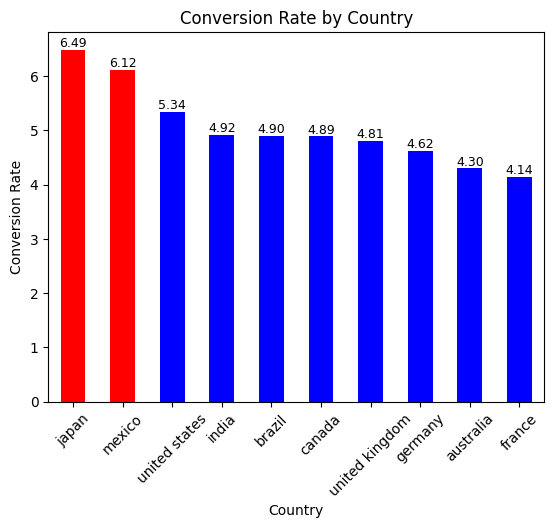

In [32]:
# Normalize country names to avoid case/space mismatches
countries = weighted_CR_sorted.index.str.strip().str.title()

# Assign colors: red for Japan & Mexico, blue for others
colors = ["red" if country in ["Japan","Mexico"] else "blue" for country in countries]

# Plot a bar graph
bar = weighted_CR_sorted.plot(kind='bar', color=colors)
plt.title('Conversion Rate by Country')
plt.ylabel('Conversion Rate')
plt.xlabel('Country')
plt.xticks(rotation=45)

# Show values above each bar
for p in bar.patches:
    bar.annotate(
        f"{p.get_height():.2f}",              # format value to 2 decimals
        (p.get_x() + p.get_width() / 2., p.get_height()),  # position at top center of bar
        ha='center', va='bottom', fontsize=9, color='black'
    )
plt.show()

### Cost Per Acquisition (CPA)

**Distribution of Cost Per Acquisition (CPA) for all ages**

In [39]:
# Count no. of purchases for all ages
conversions = df3[df3["event_type"]=="purchase"].groupby("user_age").size()

# Calc total advertising budget for all ages
budget = df3.groupby("user_age")["eq_budget"].mean()

# Compute CPA for all ages
cpa = round(budget / conversions,2)

# Create dataframe for 2 cols
cpa_ages = pd.DataFrame({
    "User_Age": budget.index,
    "CPA": cpa.values})
cpa_ages = cpa_ages.sort_values(by=['CPA','User_Age'], ascending=False)
cpa_ages

cpa_ages.head(10)

,User_Age,CPA
39,55,11845.22
42,58,6063.00
41,57,4152.45
40,56,3981.91
47,63,3907.36
35,51,3888.39
36,52,3071.80
30,46,2465.55
37,53,2399.06
49,65,2335.31


**Histogram of CPA & User Age**

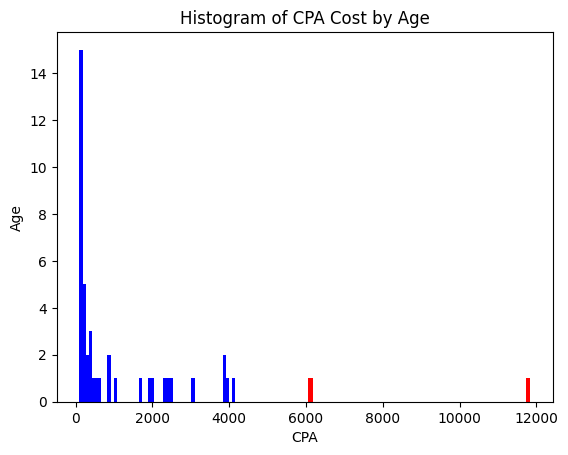

In [48]:
# Convert CPA column to numeric safely
cpa_numeric = pd.to_numeric(cpa_ages['CPA'], errors="coerce").dropna()

# Threshold: mean + 2*std
threshold = np.mean(cpa_numeric) + 2*np.std(cpa_numeric)

# Blue bars for values below threshold
plt.hist([val for val in cpa_numeric if val <= threshold],
         bins=50, alpha=1, color="blue", label="Normal")

# Red bars for values above threshold
plt.hist([val for val in cpa_numeric if val > threshold],
         bins=50, alpha=1, color="red", label="Outliers")

plt.title("Histogram of CPA Cost by Age")
plt.xlabel("CPA")
plt.ylabel("Age")
plt.show()

**Findings**

Majority of the CPA are found between 0 to $4K. Only a small group with high CPA of above $6k is skewed towards a certain age group

**1) Comparing Cost Per Acquisition (CPA) across Countries**

In [54]:
# Count no. of conversion (purchases) by country
conversions = df3[df3["event_type"]=="purchase"].groupby("country").size()

# Calc median advertising budget by country
budget = df3.groupby("country")["eq_budget"].median()

# Compute CPA for each country  
cpa = round(budget / conversions,2)

# Create dataframe for 2 col
cpa_summary = pd.DataFrame({
    "country": budget.index,
    "CPA": cpa.values})

sorted_ctry = cpa_summary.sort_values(by=['CPA','country'], ascending=False)

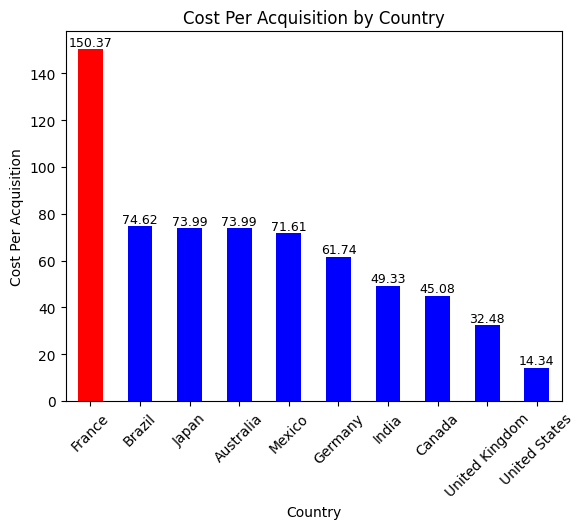

In [72]:
# Normalize country names to avoid case/space mismatches
sorted_ctry['country'] = sorted_ctry['country'].astype(str).str.strip().str.title()

# Assign colors: red for France (outlier), blue for others
colors = ["red" if country =="France" else "blue" for country in sorted_ctry['country']]

# Plot a bar graph
bar = sorted_ctry.plot(kind='bar', x='country', y='CPA', color=colors)
plt.title('Cost Per Acquisition by Country')
plt.ylabel('Cost Per Acquisition')
plt.xlabel('Country')
plt.xticks(rotation=45)

# Show values above each bar
for p in bar.patches:
    bar.annotate(
        f"{p.get_height():.2f}",              # format value to 2 dp
        (p.get_x() + p.get_width() / 2., p.get_height()),  
        ha='center', va='bottom', fontsize=9, color='black'
    )

plt.legend().remove()
plt.show()

**2) Comparing Cost Per Acquisition (CPA) across Advertisement Types**

In [104]:
# Count no. of purchases by ad_type
conversions = df3[df3["event_type"]=="purchase"].groupby("ad_type").size()

# Calc total advertising budget by ad_type
budget = df3.groupby("ad_type")["eq_budget"].median()

# Compute CPA for each ad_type
cpa = round(budget / conversions,2)

# Create dataframe for 2 col
cpa_summary = pd.DataFrame({
    "ad_type": budget.index,
    "CPA": cpa.values})

sorted_ad = cpa_summary.sort_values(by=['CPA','ad_type'], ascending=False)

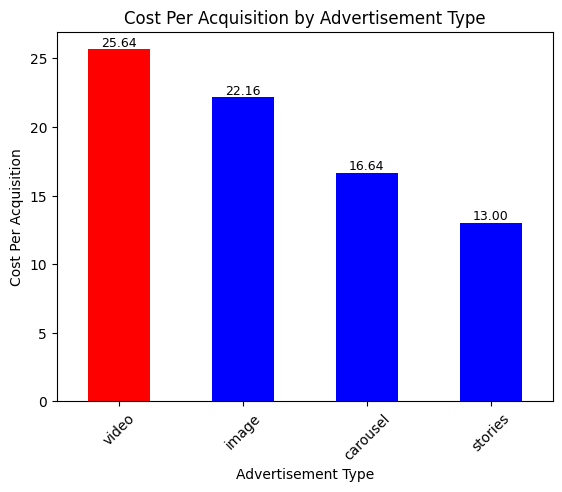

In [105]:
# Build a color list: red for video, blue for others
colors = ["red" if ad_type.lower() == "video" else "blue" 
          for ad_type in sorted_ad['ad_type']]

# Plot a bar graph
bar = sorted_ad.plot(kind='bar', x="ad_type", y="CPA", color=colors)
plt.title('Cost Per Acquisition by Advertisement Type')
plt.ylabel('Cost Per Acquisition')
plt.xlabel('Advertisement Type')
plt.xticks(rotation=45)

# Show values above each bar
for p in bar.patches:
    bar.annotate(
        f"{p.get_height():.2f}",              # format value to 2 dp
        (p.get_x() + p.get_width() / 2., p.get_height()),  
        ha='center', va='bottom', fontsize=9, color='black'
    )

plt.legend().remove()
plt.show()

**Correlation Analysis (between 2 Numerical Features CTR, CPA)**

In [94]:
df3[['w_ctr','w_cpa']].corr()

,w_ctr,w_cpa
w_ctr,1.000000,0.007345
w_cpa,0.007345,1.000000


**Finding: No multicollinearity issue between 2 numerical features**

**Correlation between Target Variable (Conversion) & 2 Numerical Features**

Conversion refers to Purchase 

In [93]:
# Point-Biserial correlation for each numerical feature vs binary target
for col in ["w_ctr", "w_cpa"]:
    corr, p_val = pointbiserialr(df3[col], df3["purchase"])
    print(f"{col} vs conversion: correlation={corr:.3f}, p-value={p_val:.3f}")

w_ctr vs conversion: correlation=-0.002, p-value=0.332
w_cpa vs conversion: correlation=-0.010, p-value=0.000


**Findings: Very low correlations, could be due to low conversion rate of 0.5%**

**Correlation Analysis (between 4 Categorical Features)**

Using Chi-square & Cramer's V method

In [96]:
selected_features = ['age_group','country','ad_type','day_of_week']

# Define function
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    return np.sqrt(chi2 / (n * (min(table.shape)-1)))

results = pd.DataFrame(index = selected_features, columns = selected_features)

for col1 in selected_features:
    for col2 in selected_features:
        if col1 == col2:
            results.loc[col1, col2] = 1.0
        else:
            results.loc[col1, col2] = cramers_v(df2[col1], df2[col2])

results = results.astype(float)
results

,age_group,country,ad_type,day_of_week
age_group,1.000000,0.031621,0.003951,0.004031
country,0.031621,1.000000,0.003327,0.005038
ad_type,0.003951,0.003327,1.000000,0.003845
day_of_week,0.004031,0.005038,0.003845,1.000000


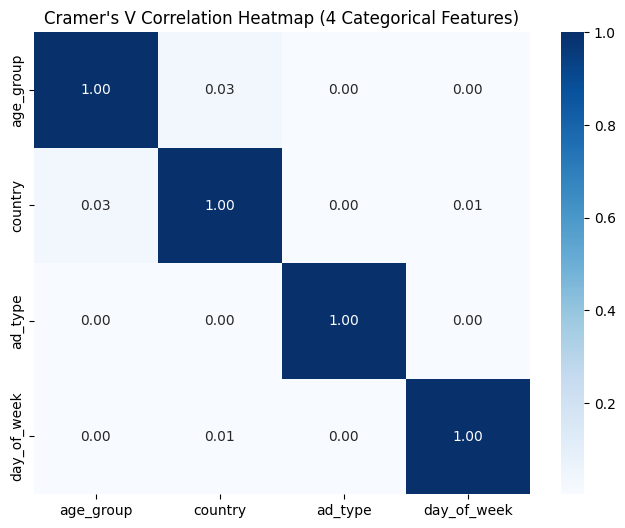

In [99]:
# Plot Correlation (among features) Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(results, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cramer's V Correlation Heatmap (4 Categorical Features)")
plt.show()

**Finding: Low correlations between the 4 categorical features, no multicollinearity issue**

**Correlation Analysis (between 4 Categorical Features & Target Variable: Conversion)**

In [100]:
# Define function
def correlation_ratio(categories, values):

    categories = pd.Categorical(categories)
    cat_means = values.groupby(categories).mean()
    grand_mean = values.mean()
    ss_between = sum(categories.value_counts()[cat] * (cat_means[cat] - grand_mean)**2 for cat in cat_means.index)
    ss_total = sum((values - grand_mean)**2)
    return np.sqrt(ss_between / ss_total)

# Define features
target = "purchase" 
selected_features = ['age_group','country','ad_type','day_of_week']

result2 = {}
for col in selected_features:
    result2[col] = correlation_ratio(df2[col], df2[target])

correlations = pd.DataFrame.from_dict(result2, orient="index", columns=["Correlation with Target Variable"])
print(correlations.round(2))

             Correlation with Target Variable
age_group                                0.00
country                                  0.01
ad_type                                  0.00
day_of_week                              0.00


**Insight: Low correlations maybe due to low conversion rate (0.5%)**